In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from statistics import mean
import joblib

In [2]:
# Remove unnecessary columns
def clean_csv(old_filename, new_filename, remove_col_list):
    try:
        df = pd.read_csv(old_filename)
        df.drop(columns=remove_col_list, inplace=True)
        # add kelly USI feature data back
        df_usi = pd.read_csv("../data/uci_phishing_url_dataset_reduced_feature_var.csv")
        col = df.pop("IsLegit")
        df = pd.concat([df, df_usi[["Levenshtein", "JaroWinkler", "LCS"]]], axis=1)
        # Add is Legit column back
        df.insert(len(df.columns), "IsLegit", col)
        df.to_csv(new_filename, index=False)

        print(f'file: "{old_filename}" cleaned successfully')
        return True
    except Exception as e:
        print(f'file: "{old_filename}" clean failed ({e})')
        return False

In [3]:
# Loads features and target variables
def load_data(filename, y_target_name, num_rows=-1, pos=0, isUCI_data: bool = True):
    df = pd.read_csv(filename)
    if not isUCI_data:
        df["Label"] = df["Label"].map({"Phishing": 0, "Legitimate": 1})
        df.rename(columns={"Label": "IsLegit"}, inplace=True)

    if num_rows > 0:
        df = df[pos : pos + num_rows]
    elif pos != 0:
        df = df[pos:]

    X = df.drop(columns=[y_target_name, "URL"])
    y = df[y_target_name]

    return X, y, df

In [4]:
def show_corr_matrix(df, output_filename):
    non_valid_cols = [
        df.columns[i]
        for i, item in enumerate(df.dtypes)
        if not pd.api.types.is_numeric_dtype(item)
    ]
    df.drop(columns=non_valid_cols, inplace=True)
    matrix = df.corr()
    plt.figure(figsize=(32, 16))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("UCI Phishing URL Correlation Heatmap")
    plt.savefig(output_filename)

In [5]:
def get_training_test_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
    return X_train, X_test, y_train, y_test

In [6]:
def logistic_regression_model_training(X_train, X_test, y_train, y_test):
    # Speed up cos -4,4 is too slow
    C_grid = np.logspace(-3, 3, 20)
    y_train_log_loss_data = []
    y_test_log_loss_data = []
    for i, C in enumerate(C_grid):
        print(f"working on {i} with C value: {C:.4f}")
        clf = LogisticRegression(C=C, l1_ratio=0, solver="lbfgs", max_iter=500).fit(
            X_train, y_train
        )
        y_train_pred = clf.predict_proba(X_train)
        y_test_pred = clf.predict_proba(X_test)
        y_train_log_loss = log_loss(y_train, y_train_pred)
        y_test_log_loss = log_loss(y_test, y_test_pred)

        # print(f"{y_train_pred=}")
        # print(f"{y_test_pred=}")
        print(f"{y_train_log_loss=:.4f}")
        print(f"{y_test_log_loss=:.4f}")
        y_train_log_loss_data.append(y_train_log_loss)
        y_test_log_loss_data.append(y_test_log_loss)

    plt.figure()
    plt.plot(
        C_grid,
        y_train_log_loss_data,
        "o-",
        color="blue",
        label="Training Data Log-Loss",
        markersize=3,
    )
    plt.plot(
        C_grid,
        y_test_log_loss_data,
        "o-",
        color="red",
        label="Test Data Log-Loss",
        markersize=3,
    )

    plt.xlabel("C")
    plt.ylabel("Log-Loss")
    plt.title("Log-Loss of Training and Test Data Vs C")
    # plt.ylim([0, 1])
    plt.xscale("log")
    plt.legend()
    plt.savefig("../outputs/logistic_regression_log_loss_c.png")

# Add kelly's calculated feature variables into the new data

In [7]:
# df_usi = pd.read_csv("../data/uci_phishing_url_dataset_reduced_feature_var.csv")
# pd.concat([df, df_usi[["Levenshtein", "JaroWinkler", "LCS"]]], axis=1)

In [8]:
clean_csv(
    "../data/uci_phishing_url_dataset.csv",
    "../data/uci_phishing_url_dataset_clean.csv",
    [
        "Domain",
        "TLD",
        "Title",
        "DomainTitleMatchScore",
        "IsResponsive",
        "NoOfURLRedirect",
        "NoOfSelfRedirect",
        "HasDescription",
        "NoOfPopup",
        "NoOfiFrame",
        "HasExternalFormSubmit",
        "HasHiddenFields",
        "HasPasswordField",
        "Bank",
        "Pay",
        "Crypto",
        "NoOfImage",
        "NoOfCSS",
        "URLSimilarityIndex",
        "TLDLegitimateProb",
        "URLCharProb",
    ],
)

file: "../data/uci_phishing_url_dataset.csv" cleaned successfully


True

remove "FILENAME" column from data


# Why hardcode this data for ur USI columns?? @kellyyyc T_T not extensible is it?

In [18]:
# X, y, df = load_data("../data/uci_phishing_url_dataset_reduced_feature_var.csv", "IsLegit", 100000)
CSV_PATH = "../data/uci_phishing_url_dataset_clean.csv"
# CSV_PATH = "../data/url_test_data_compatible_with_model.csv"
X, y, df = load_data(CSV_PATH, "IsLegit", False)

In [19]:
df

,URL,URLLength,DomainLength,IsDomainIP,CharContinuationRate,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,...,HasSubmitButton,HasCopyrightInfo,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,Levenshtein,JaroWinkler,LCS,IsLegit
0,https://www.southbankmosaics.com,32,24,0,1.000000,3,1,0,0,0.0,...,1,1,28,119,0,124,0.700000,0.890420,0.750000,1
1,https://www.uni-mainz.de,24,16,0,0.666667,2,1,0,0,0.0,...,1,1,8,39,0,217,1.000000,1.000000,1.000000,1
2,https://www.voicefmradio.co.uk,30,22,0,0.866667,2,2,0,0,0.0,...,1,1,7,42,2,5,0.722222,0.873504,0.812500,1
3,https://www.sfnmjournal.com,27,19,0,1.000000,3,1,0,0,0.0,...,1,1,15,22,1,31,0.866667,0.931746,0.896552,1
4,https://www.rewildingargentina.org,34,26,0,1.000000,3,1,0,0,0.0,...,1,1,34,72,1,85,0.681818,0.863876,0.731707,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,https://www.skincareliving.com,29,22,0,1.000000,3,1,0,0,0.0,...,1,1,21,187,2,191,0.666667,0.904040,0.750000,1
235791,https://www.winchester.gov.uk,28,21,0,0.785714,2,2,0,0,0.0,...,1,0,7,88,0,31,1.000000,1.000000,1.000000,1
235792,https://www.nononsensedesign.be,30,23,0,1.000000,2,1,0,0,0.0,...,1,1,30,58,2,67,0.550000,0.713158,0.666667,1
235793,https://patient-cell-40f5.updatedlogmylogin.wo...,55,47,0,0.465116,3,2,0,0,0.0,...,1,0,3,0,0,0,0.319149,0.733095,0.463415,0


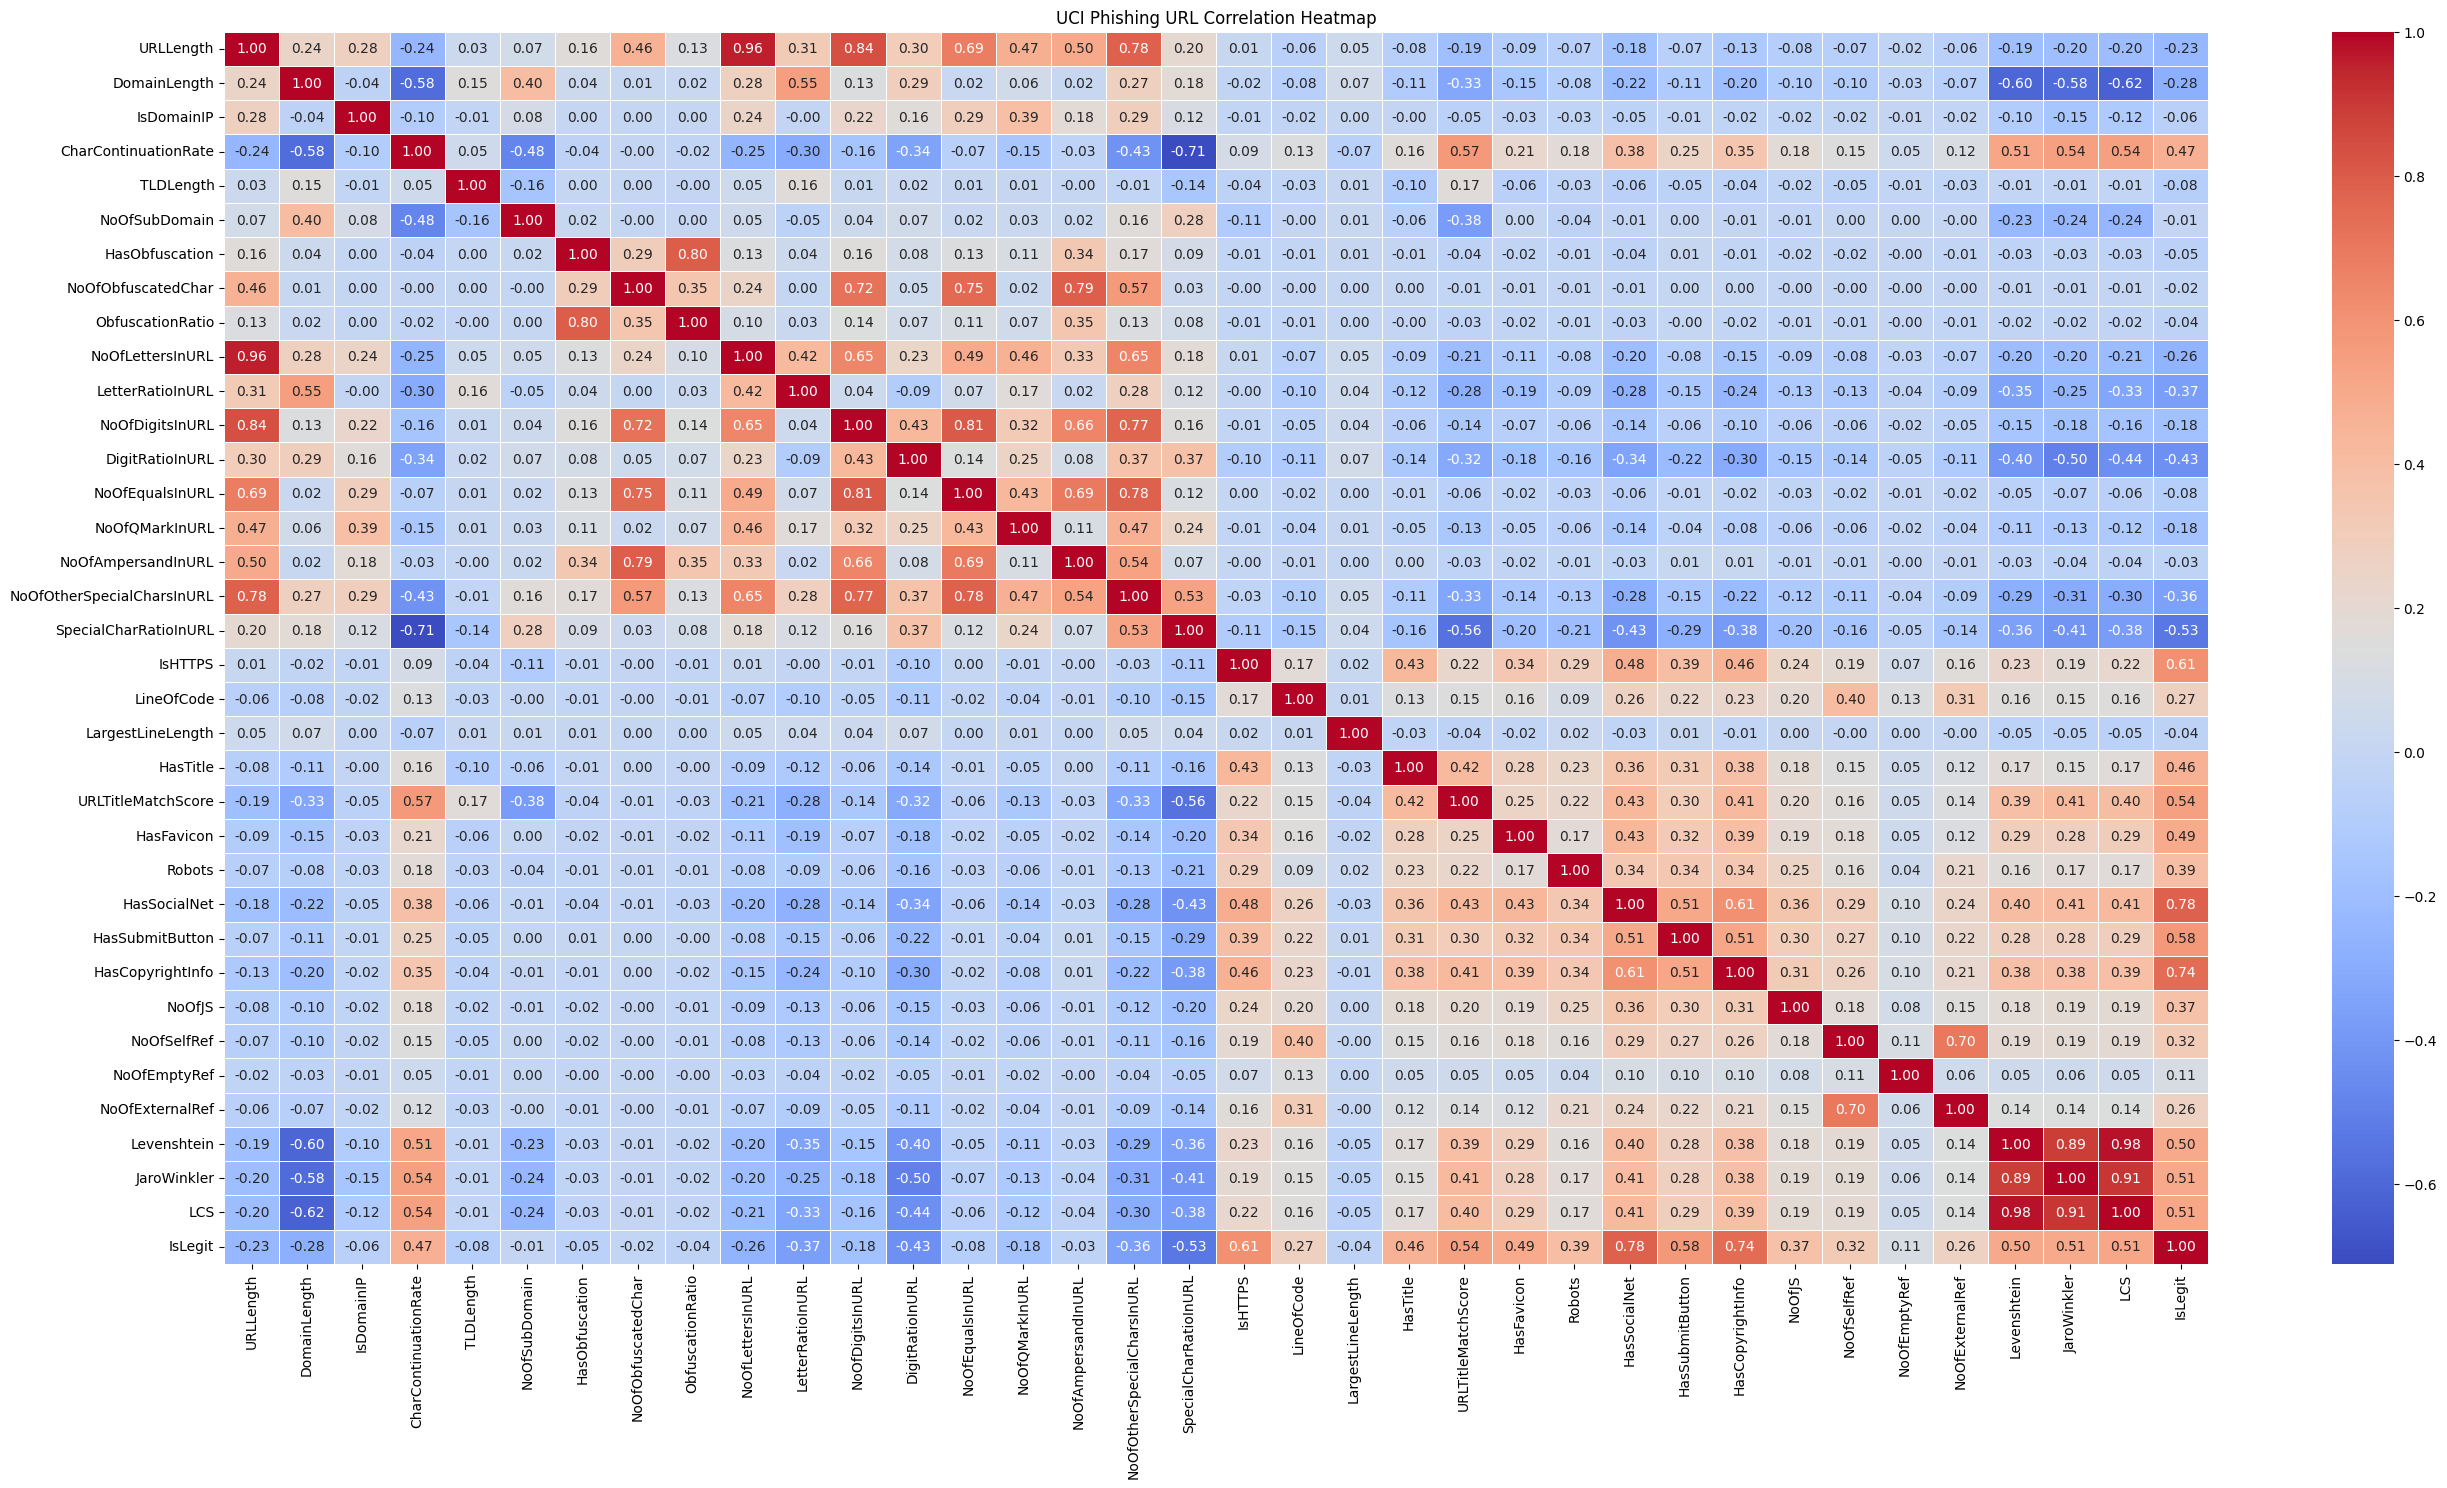

In [20]:
show_corr_matrix(df, "../outputs/corr_matrix-2.png")

working on 0 with C value: 0.0010


/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


y_train_log_loss=0.0116
y_test_log_loss=0.0120
working on 1 with C value: 0.0021


/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


y_train_log_loss=0.0096
y_test_log_loss=0.0097
working on 2 with C value: 0.0043


...

y_train_log_loss=0.0024
y_test_log_loss=0.0023
working on 18 with C value: 483.2930


/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


y_train_log_loss=0.0032
y_test_log_loss=0.0029
working on 19 with C value: 1000.0000


/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.0034
y_test_log_loss=0.0031


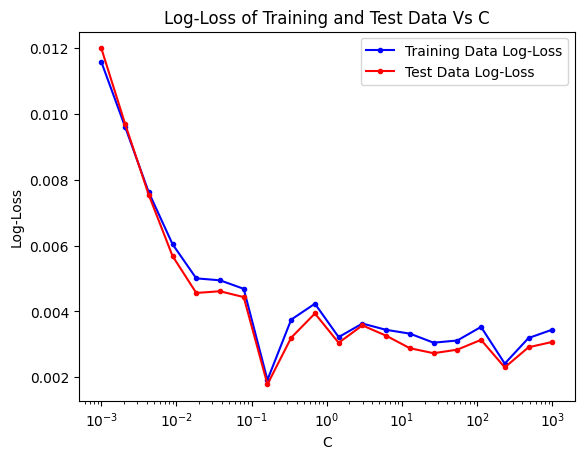

In [21]:
X_train, X_test, y_train, y_test = get_training_test_data(X, y)
logistic_regression_model_training(X_train, X_test, y_train, y_test)

In [22]:
clf = LogisticRegression(C=5, l1_ratio=0, solver="lbfgs", max_iter=500).fit(
    X_train, y_train
)
joblib.dump(
    {"features": X_train.columns.tolist(), "model": clf},
    "../models/logit_model-py3.10.pkl",
)

/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


['../models/logit_model-py3.10.pkl']

In [13]:
model_dump = joblib.load("../models/logit_model-py3.10.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_new, df_new = load_data(
    "../data/uci_phishing_url_dataset_clean.csv", "IsLegit", pos=100000
)
print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])

accuracy = accuracy_score(y_new, y_new_pred)
print(f"Accuracy: {accuracy}")

[[-4.43795575e+00  8.26612659e+00 -8.63420920e-03  4.37987686e+00
   5.64396371e-01  2.97032724e+00 -6.16798430e-01 -4.62463988e-01
  -2.72564122e-03 -1.53507562e-02 -1.92503587e-04 -3.79663015e+00
  -7.29660586e-01 -4.41318443e+00 -2.05779776e-01 -3.94933727e-02
  -4.12531290e-02 -5.11944395e-03 -4.66751693e+00 -1.07823227e-01
   1.74057230e+01]]
Accuracy: 0.9976508707978938


## Test against another external dataset

In [23]:
model_dump = joblib.load("../models/logit_model.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_true, df_new = load_data(
    "../data/url_test_data_compatible-st-1.csv",
    "IsLegit",
)
# print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])

accuracy = accuracy_score(y_true, y_new_pred)
print(f"Accuracy: {accuracy}")

/home/otter/.local/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.8.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Accuracy: 0.86


# compare between y_pred and y_expected:

In [6]:
y_new_pred

array([1, 1, 1, ..., 0, 0, 1], shape=(1141,))

In [7]:
y_true

0       1
1       1
2       1
3       1
4       1
       ..
1136    1
1137    1
1138    1
1139    1
1140    1
Name: IsLegit, Length: 1141, dtype: int64